# Energy Reconstruction Using CNN - Both Charges

In [21]:
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt

from datetime import datetime

#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import Dense, Conv2D, Flatten
#from tensorflow.keras.callbacks import ModelCheckpoint

from data_tools import load_preprocessed, dataPrep, nameModel

simPrefix = os.getcwd()+'\\simdata'

## Data Input

In [2]:
x, y = load_preprocessed(simPrefix, 'train')

Percentage of events with a NaN: 2.68


In [3]:
print(x.shape)
print(y.keys())
# each station has 2 tanks, each tank has 2 DOMs (high/log gain)
# each tank measures charge and time
# each station gives 2 charges and 2 times, 4 total pieces of data per station
# stations arranged in 10x10 square lattice, 2 corners of square unused
# charge measured in VEM, vertical equivalent muon

# 'dir' is true direction, rest of dir are reconstruted by simulations
# 'plane_dir' assumes shower is flat plane
# 'laputop_dir' performs likelihood analysis
# 'small_dir' compromises between plane and laputop

(549773, 10, 10, 4)
dict_keys(['comp', 'energy', 'dir', 'plane_dir', 'laputop_dir', 'small_dir'])


In [4]:
# 85/15 split for training/validation
energy = y['energy']
comp = y['comp']
theta, phi = y['dir'].transpose()
nevents = len(energy)
trainCut = (np.random.uniform(size=nevents) < 0.85)
testCut = np.logical_not(trainCut)

## Model Training

### Alpha Model
- Input: no charge merge, no time layers included, normalized data, combined with cosine of zenith angle
- Layers: Two convolutional layers for charge, then combined with zenith
- Output: Energy

In [5]:
# Name for model
key = 'zenith'
i = 0
while(os.path.exists('models/model_{}.h5'.format(key+str(i)))):
    i = i + 1
key = key+str(i)
numepochs = 10
# Data preparation: no merging of charge (q), no time layers included (t=False), data normalized from 0-1
prep = {'q':None, 't':False, 'normed':True, 'reco':'plane','cosz':True}

In [6]:
key

'zenith0'

In [7]:
# Establish arrays to be trained on
x_i = dataPrep(x, y, **prep)
temp_y = energy

In [29]:
x_new = x_i[1]
cut = ~np.isnan(x_new)

In [31]:
x_new[cut].shape
x_new[cut].reshape(-1,1).shape

(540381, 1)

In [26]:
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)
diabetes_X = diabetes_X[:, np.newaxis, 2]
diabetes_X.shape

(442, 1)

In [44]:
x = x_new[cut]
y = energy[cut]
reg=np.polyfit(x,y,1)

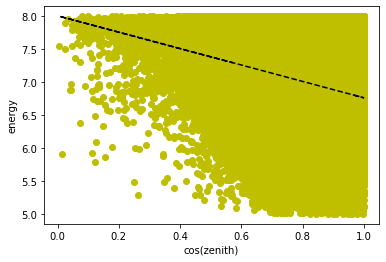

In [50]:
poly1d_fn = np.poly1d(reg)
plt.xlabel('cos(zenith)')
plt.ylabel('energy')
plt.plot(x,y, 'yo', x, poly1d_fn(x), '--k')